<a href="https://colab.research.google.com/github/ankan-git-coder/Deep-learning-COURSE/blob/main/five_flower_classification_googlenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lara311/flowers-five-classes")

print("Path to dataset files:", path)

100%|██████████| 158M/158M [00:00<00:00, 231MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/lara311/flowers-five-classes/versions/1


In [8]:
import os
print(os.listdir(path))

['train']


In [9]:
data_dir = os.path.join(path, "train")
print(os.listdir(data_dir))

['tulip', 'daisy', 'sunflower', 'rose', 'dandelion']


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [11]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [12]:
full_dataset = datasets.ImageFolder(root=data_dir)

# Stratified split ensures equal distribution of the 5 flower types
train_idx, val_idx = train_test_split(
    list(range(len(full_dataset))),
    test_size=0.2,
    stratify=full_dataset.targets,
    random_state=42
)

# Create Subsets with specific transforms
train_set = Subset(datasets.ImageFolder(data_dir, train_transforms), train_idx)
val_set = Subset(datasets.ImageFolder(data_dir, val_transforms), val_idx)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load pre-trained GoogLeNet
model = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT)

# Freeze all layers (we don't want to change the pre-trained features)
for param in model.parameters():
    param.requires_grad = False

# Replace the final layer (model.fc) for 5 flower classes
model.fc = nn.Linear(model.fc.in_features, 5)

# Ensure the new layer is trainable
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

Using device: cuda
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 178MB/s]


In [14]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [17]:
EPOCHS = 25
history = {'loss': [], 'train_acc': [], 'val_acc': []}

print("Starting Training...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total
    avg_loss = running_loss / len(train_loader)

    # Validation Phase
    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            v_total += labels.size(0)
            v_correct += predicted.eq(labels).sum().item()

    val_acc = 100. * v_correct / v_total

    # Log history
    history['loss'].append(avg_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

Starting Training...
Epoch 1/25 | Loss: 0.3889 | Train Acc: 86.25% | Val Acc: 88.36%
Epoch 2/25 | Loss: 0.3917 | Train Acc: 86.43% | Val Acc: 88.18%
Epoch 3/25 | Loss: 0.3838 | Train Acc: 86.52% | Val Acc: 88.18%
Epoch 4/25 | Loss: 0.3616 | Train Acc: 87.52% | Val Acc: 88.00%
Epoch 5/25 | Loss: 0.3660 | Train Acc: 86.48% | Val Acc: 88.18%
Epoch 6/25 | Loss: 0.3747 | Train Acc: 85.88% | Val Acc: 87.82%
Epoch 7/25 | Loss: 0.3738 | Train Acc: 86.52% | Val Acc: 88.91%
Epoch 8/25 | Loss: 0.3482 | Train Acc: 87.57% | Val Acc: 88.36%
Epoch 9/25 | Loss: 0.3572 | Train Acc: 88.02% | Val Acc: 88.36%
Epoch 10/25 | Loss: 0.3591 | Train Acc: 87.43% | Val Acc: 88.73%
Epoch 11/25 | Loss: 0.3555 | Train Acc: 87.52% | Val Acc: 88.00%
Epoch 12/25 | Loss: 0.3671 | Train Acc: 86.79% | Val Acc: 88.91%
Epoch 13/25 | Loss: 0.3566 | Train Acc: 87.16% | Val Acc: 88.73%
Epoch 14/25 | Loss: 0.3571 | Train Acc: 87.16% | Val Acc: 88.00%
Epoch 15/25 | Loss: 0.3462 | Train Acc: 87.02% | Val Acc: 87.64%
Epoch 16/25 |

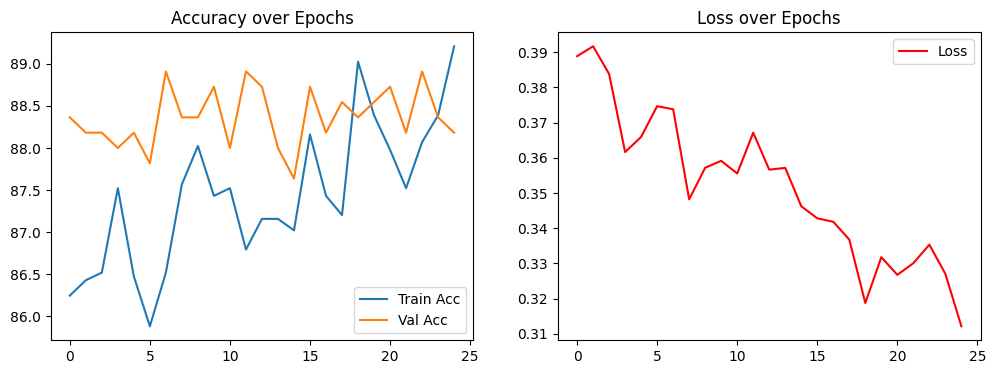

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Loss', color='red')
plt.title('Loss over Epochs')
plt.legend()

plt.show()